# Decision Tree from Scratch

This notebook demonstrates a simple Decision Tree classifier implemented from scratch.

A decision tree recursively splits the data based on feature thresholds in order to reduce impurity and improve class separation.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

from ml_scratch.tree.decision_tree import DecisionTree
from ml_scratch.metrics import accuracy_score

## 1. Generate Synthetic Classification Data

We create a simple 2D dataset for binary classification so that the tree's decision regions can be visualized clearly.

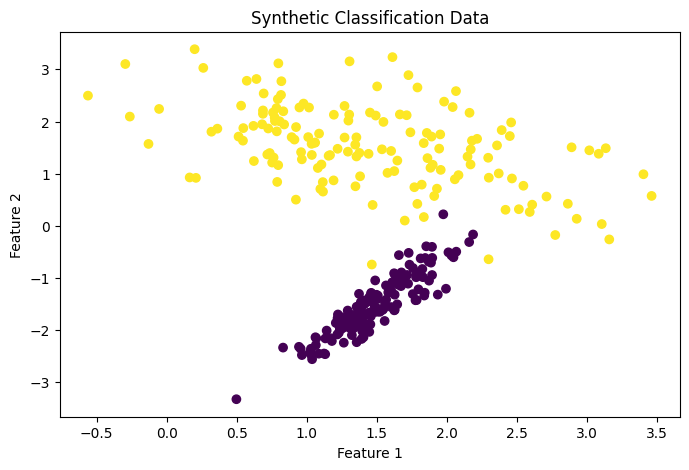

In [2]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Synthetic Classification Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 2. Model Overview

A decision tree makes predictions by repeatedly asking questions of the form:

"Is feature_j <= threshold?"

At each node, the algorithm chooses the split that best separates the classes.

A common impurity measure is Gini Impurity:

Gini = 1 - Σ p_i^2

Where p_i is the proportion of samples belonging to class i in the node.

The tree keeps splitting until a stopping condition is met, such as:
- maximum depth reached
- node becomes pure
- too few samples remain

In [3]:
model = DecisionTree(max_depth=3)
model.fit(X, y)

y_pred = model.predict(X)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9933333333333333


## 3. Decision Boundary

Because the decision tree uses axis-aligned splits, the boundary is usually piecewise rectangular.

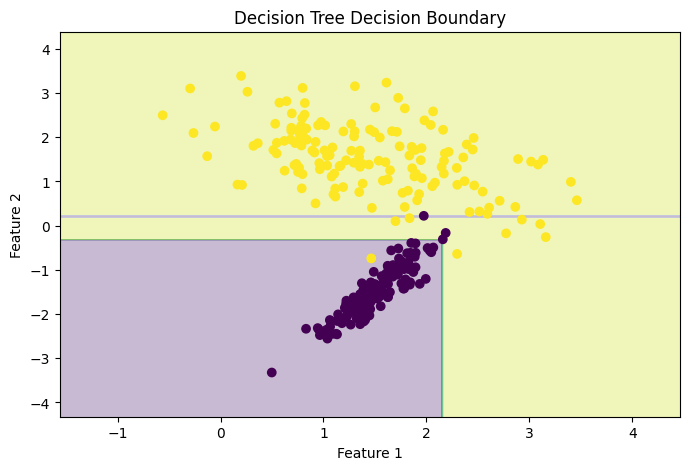

In [4]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Decision Tree Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 4. Prediction Check

In [5]:
print("First 10 predictions:", y_pred[:10])
print("First 10 labels:     ", y[:10])

First 10 predictions: [0 1 0 1 1 0 1 1 1 0]
First 10 labels:      [0 1 0 1 1 0 1 1 1 0]


## 5. Conclusion

- Decision trees are easy to interpret and work well on non-linear classification problems.
- The model creates rules by recursively splitting the feature space.
- Unlike linear models, decision trees can produce non-linear decision regions.
- However, shallow trees may underfit, while very deep trees may overfit.